# FFHQ Demographic Vulnerability Analysis

## Modules and packages

In [56]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# EDA (Exploratory Data Analysis)

In [65]:
#Wednesday 18 March 2026 10:28:35 GMT by MAPA

# ffhq metadata path
ffhq_json_path = "../../data/ffhq_real_demographics_meta_data.json"

with open(ffhq_json_path) as f:
    data = json.load(f)

# Exctact demographics
demographics = data[0]["Demographics"]

df = pd.DataFrame(demographics)

print(df.info(), df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69997 entries, 0 to 69996
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   File             69997 non-null  object 
 1   asian            69997 non-null  float64
 2   indian           69997 non-null  float64
 3   black            69997 non-null  float64
 4   white            69997 non-null  float64
 5   middle eastern   69997 non-null  float64
 6   latino hispanic  69997 non-null  float64
 7   age              69997 non-null  float64
 8   Woman            69997 non-null  float64
 9   Man              69997 non-null  float64
dtypes: float64(9), object(1)
memory usage: 5.3+ MB
None               asian        indian         black         white  middle eastern  \
count  69997.000000  69997.000000  69997.000000  69997.000000    69997.000000   
mean      18.103074      4.435273      5.975263     49.183342        9.433812   
std       31.357766      9.909866     1

In [58]:
# set some labels for analysis

race_cols = ["asian", "indian", "black", "white", "middle eastern", "latino hispanic"]

df["dominant_race"] = df[race_cols].idxmax(axis=1)

df["gender"] = df[["Man", "Woman"]].idxmax(axis=1)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["<18", "18-30", "30-45", "45-60", "60+"]
)

<Axes: ylabel='count'>

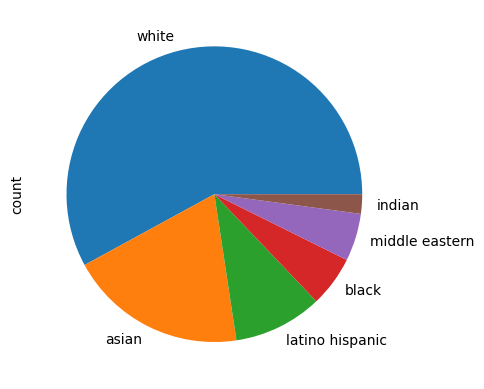

In [ ]:
# Basic exploration
# df["dominant_race"].value_counts().plot(kind="bar", title="Race distribution")
df["dominant_race"].value_counts().plot(kind="pie")

<Axes: title={'center': 'Gender DIstribution'}, xlabel='gender'>

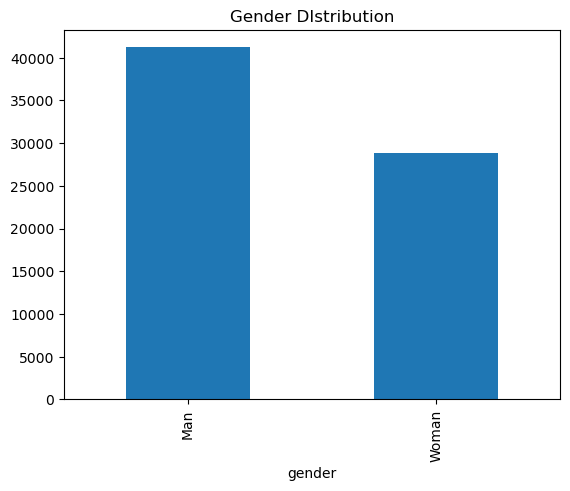

In [60]:
df["gender"].value_counts().plot(kind="bar", title="Gender DIstribution")

Text(0, 0.5, 'Freq')

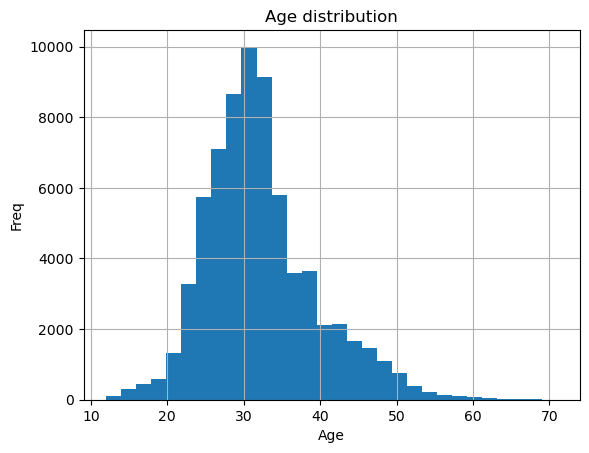

In [61]:
# Age distribution
df["age"].hist(bins=30) 
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Freq")

Text(0, 0.5, 'Freq')

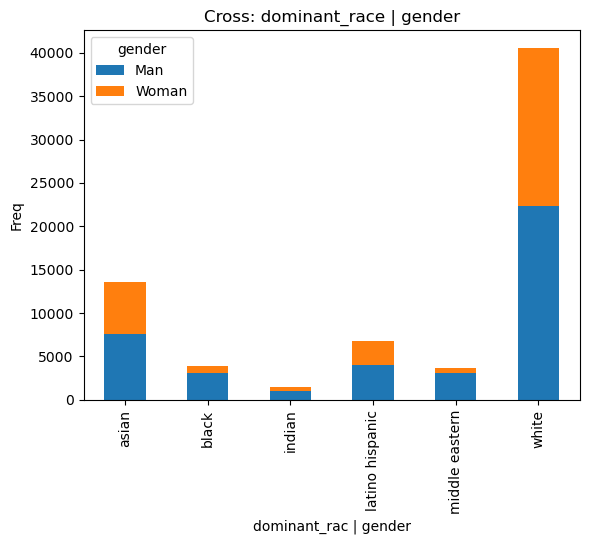

In [62]:
pd.crosstab(df["dominant_race"], df["gender"]).plot(kind="bar", stacked=True)
plt.title("Cross: dominant_race | gender")
plt.xlabel("dominant_rac | gender")
plt.ylabel("Freq")

In [63]:
pd.crosstab(df["dominant_race"], df["age_group"])

age_group,<18,18-30,30-45,45-60,60+
dominant_race,,,,,
asian,387,7330,5336,524,30
black,11,1835,1885,149,3
indian,6,651,752,78,2
latino hispanic,118,3157,3148,379,4
middle eastern,5,1507,1827,303,7
white,542,16785,20331,2810,95


Text(0, 0.5, 'Freq')

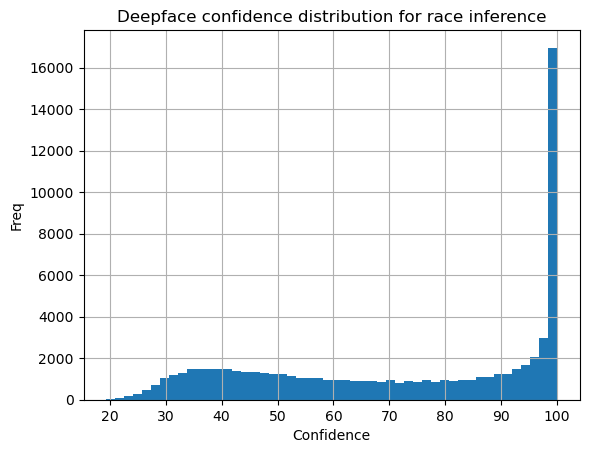

In [64]:
# Deep face confidence distribution for race inference
df["race_confidence"] = df[race_cols].max(axis=1)
df["race_confidence"].hist(bins=50)
plt.title("Deepface confidence distribution for race inference")
plt.xlabel("Confidence")
plt.ylabel("Freq")